# Comparing number of landmarks vs registration accuracy

In [1]:
#THIS BLOCK CONTAINS THE FUNCTIONS, THE NEXT CONTAINS THE PIPELINE/USAGE

import numpy as np
import pandas as pd
import os
from skimage import transform
from skimage import io
from sklearn import metrics

#reading coordinates
def read_points(filename):
    df = pd.read_csv(filename)
    points = df[['axis.1', 'axis.0']].values
    return points


#calculating the affine transformation
def calculate_affine_transform(fixed_points, moving_points, ):
    fixed_points = np.array(fixed_points)
    moving_points = np.array(moving_points)

    tform = transform.AffineTransform()
    tform.estimate(moving_points, fixed_points)

    affine_matrix = tform.params

    #calculate residual error
    transformed_points = tform(moving_points)
    residuals = np.sqrt(np.sum((transformed_points - fixed_points)**2, axis=1))
    mean_error = np.mean(residuals)
    max_error = np.max(residuals)

    
    return affine_matrix, mean_error, max_error


#apply the affine transformation

def apply_affine_registration(moving_image, affine_matrix):

    # Create transform object from your matrix
    tform = transform.AffineTransform(matrix=affine_matrix)
    
    # Apply transformation
    registered_image = transform.warp(
        moving_image,
        tform.inverse,  # warp uses inverse mapping
        output_shape=moving_image.shape,
        preserve_range=True
    ).astype(moving_image.dtype)
    
    return registered_image

In [25]:
#load images
import tifffile as tf
import pandas as pd
from pathlib import Path
from collections import defaultdict

fixed = tf.imread(r"D:\Dom\Psoriasis project\4th year data\xen_pheno_registration\systematising landmarks\Landmark csvs\replicate3\spaced\registered_pheno_C12.tif")
moving = tf.imread(r"D:\Dom\Psoriasis project\4th year data\xen_pheno_registration\systematising landmarks\Landmark csvs\replicate3\spaced\pheno_C12.tif") #cd4 is pheno12

points_path = Path(r"D:\Dom\Psoriasis project\4th year data\xen_pheno_registration\systematising landmarks\Landmark csvs\replicate3\spaced\landmarks")

#load coords
fixed_coords = {}
for file in points_path.glob("*xen*"):
    name = file.stem.split("_")[0].removesuffix("xen")
    fixed_coords[name] = read_points(file)

moving_coords = {}
for file in points_path.glob("*pheno*"):
    name = file.stem.split("_")[0].removesuffix("pheno")
    moving_coords[name] = read_points(file)

def calc_f1(fixed_points, moving_points):

    #calculate the affine matrix
    affine_matrix, mean_error, max_error = calculate_affine_transform(fixed_points, moving_points)

    #register the moving image
    registered = apply_affine_registration(moving, affine_matrix)

    #calculate fscore/dice score between registered and moving image - requires conversion to a 1D binary array
    fixed_binary = (fixed >0).astype(np.uint8).ravel()
    registered_binary = (registered >0).astype(np.uint8).ravel()
        

    f1_score = metrics.f1_score(fixed_binary, registered_binary)
    
    return f1_score, mean_error, max_error

results = defaultdict(list)

for num, points in fixed_coords.items():
    results['num'].append(num)
    
    moving_points = moving_coords[num]
    f1, merr, maxerr = calc_f1(points, moving_points)

    results['fscore'].append(f1)
    results['mean_error_px'].append(merr)
    results['max_error_px'].append(maxerr)

#converting errors from pixels to microns
results_table = pd.DataFrame(results)
results_table['mean_error_um'] = results_table["mean_error_px"] / 1.972
results_table['max_error_um'] = results_table["max_error_px"] / 1.972

results_table.to_csv(r"D:\Dom\Psoriasis project\4th year data\xen_pheno_registration\systematising landmarks\Landmark csvs\replicate3\spaced\affine_results.csv")
results_table


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_32340\4260719262.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `AffineTransform.from_estimate` class constructor instead.
  tform.estimate(moving_points, fixed_points)
C:\Users\dbuxton\AppData\Local\Temp\ipykernel_32340\4260719262.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `AffineTransform.from_estimate` class constructor instead.
  tform.estimate(moving_points, fixed_points)
C:\Users\dbuxton\AppData\Local\Temp\ipykernel_32340\4260719262.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `AffineTransform.from_estimate` class constructor instead.
  tform.estimate(moving_points, fixed_points)
C:\Users\dbuxton\AppData\Local\Temp\ipykernel_32340\4260719262.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in versi

,num,fscore,mean_error_px,max_error_px,mean_error_um,max_error_um
0,5,0.535945,0.652069,0.875344,0.330664,0.443886
1,10,0.552032,0.894796,1.878681,0.453751,0.952678
2,15,0.605894,1.141159,2.274311,0.578681,1.153302
3,20,0.612613,1.076566,2.163104,0.545926,1.096909
4,25,0.632460,1.195259,2.161466,0.606115,1.096078
5,30,0.639448,1.191122,2.376906,0.604017,1.205328
6,35,0.629383,1.203590,3.015229,0.610340,1.529021
7,40,0.643106,1.215567,3.052994,0.616413,1.548171
8,45,0.625904,3.771762,48.224098,1.912658,24.454411
9,50,0.728697,4.321613,50.808505,2.191487,25.764962


# Plotting results

In [ ]:
rep1 = pd.read_csv(r"D:\Dom\Psoriasis project\4th year data\xen_pheno_registration\systematising landmarks\Landmark csvs\replicate1\spaced\affine_results.csv")
rep2 = pd.read_csv(r"D:\Dom\Psoriasis project\4th year data\xen_pheno_registration\systematising landmarks\Landmark csvs\replicate2\spaced\affine_results.csv")
rep3 = pd.read_csv(r"D:\Dom\Psoriasis project\4th year data\xen_pheno_registration\systematising landmarks\Landmark csvs\replicate3\spaced\affine_results.csv")

for rep in [rep1, rep2, rep3]:
    rep['relative_fscore'] = rep['fscore'] /rep['fscore'][9]

0    0.861850
1    0.919361
2    0.962637
3    0.986027
4    0.988585
5    0.985953
6    0.997076
7    0.997986
8    0.993981
9    1.000000
Name: relative_fscore, dtype: float64
0    0.713634
1    0.724523
2    0.688169
3    0.777463
4    0.825391
5    0.906329
6    0.904080
7    0.912190
8    0.974876
9    1.000000
Name: relative_fscore, dtype: float64
0    0.735484
1    0.757560
2    0.831477
3    0.840697
4    0.867934
5    0.877523
6    0.863711
7    0.882543
8    0.858937
9    1.000000
Name: relative_fscore, dtype: float64


In [30]:
rep1

,Unnamed: 0,num,fscore,mean_error_px,max_error_px,mean_error_um,max_error_um,relative_fscore
0,0,5,0.746855,0.734836,1.071395,0.372635,0.543304,0.861850
1,1,10,0.796692,1.929974,3.917172,0.978688,1.986396,0.919361
2,2,15,0.834195,2.162087,3.505928,1.096393,1.777854,0.962637
3,3,20,0.854464,2.101578,3.875876,1.065709,1.965454,0.986027
4,4,25,0.856680,2.188877,4.118664,1.109978,2.088572,0.988585
5,5,30,0.854399,2.493425,8.500414,1.264414,4.310555,0.985953
6,6,35,0.864038,2.529643,9.329738,1.282781,4.731105,0.997076
7,7,40,0.864826,2.412317,9.869829,1.223284,5.004984,0.997986
8,8,45,0.861356,2.552893,10.057202,1.294570,5.100001,0.993981
9,9,50,0.866572,2.548547,10.770484,1.292367,5.461706,1.000000


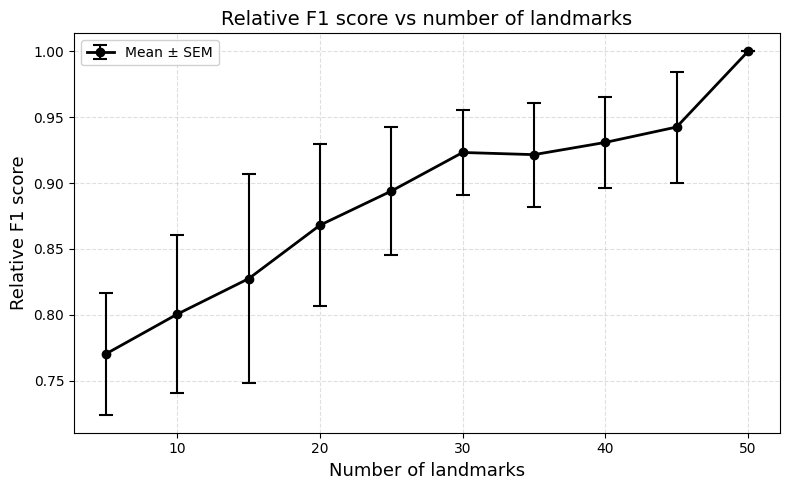

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

replicates = [rep1, rep2, rep3]

#merge all replicates on 'num', compute mean +/- std at each num value
combined = (
    pd.concat(replicates).groupby('num')['relative_fscore']
    .agg(mean='mean', std=lambda x: x.std()/ np.sqrt(len(x))).reset_index()
)


fig, ax = plt.subplots(figsize=(8,5))

#plot mean and error bars
ax.errorbar(
    combined['num'], combined['mean'],
    yerr = combined['std'],
    fmt= 'o-', color = 'black', linewidth=2,
    capsize=5, capthick=1.5, elinewidth=1.5,
    zorder = 4, label='Mean ± SEM'
)

ax.set_xlabel('Number of landmarks', fontsize = 13)
ax.set_ylabel('Relative F1 score', fontsize =13)
ax.set_title('Relative F1 score vs number of landmarks', fontsize = 14)
ax.legend(framealpha =0.9)
ax.grid(True, linestyle = '--', alpha = 0.4)

plt.tight_layout()
plt.show()

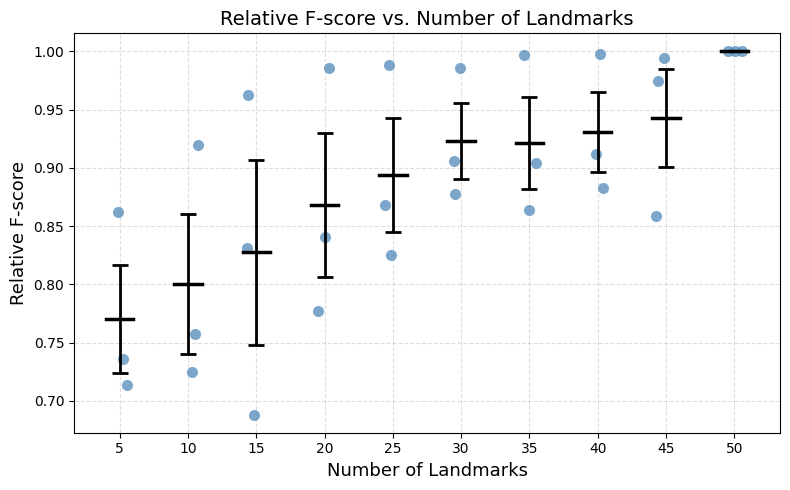

In [52]:
import seaborn as sns

# Stack all replicates into a long-format DataFrame
combined = (
    pd.concat(replicates)
    .groupby('num')['relative_fscore']
    .agg(mean='mean', sem=lambda x: x.std() / np.sqrt(len(x)))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

# Plot individual replicate points, jittered slightly so they don't overlap
sns.stripplot(
    data=combined_long, x='num', y='relative_fscore',
    ax=ax, color='steelblue', size=8, jitter=0.15, alpha=0.7, zorder=3
)

# Overlay mean ± 95% CI error bars
ax.errorbar(
    range(len(combined['num'])), combined['mean'],
    yerr=combined['sem'],  # whichever CI method you chose
    fmt='none', color='black', capsize=6, capthick=2, elinewidth=2, zorder=4
)

# Add a horizontal mean bar
for i, row in combined.iterrows():
    ax.plot([i - 0.2, i + 0.2], [row['mean'], row['mean']],
            color='black', linewidth=2.5, zorder=5)

ax.set_xlabel('Number of Landmarks', fontsize=13)
ax.set_ylabel('Relative F-score', fontsize=13)
ax.set_title('Relative F-score vs. Number of Landmarks', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()